---

# `KilonovaSCORER` (v0.1.0): Simulation-Based Scoring System for Kilonova Candidates


`KilonovaSCORER` is a simulation-driven statistical framework designed to evaluate and rank transient candidates according to their compatibility with physically motivated kilonova light-curve models. The package is optimized for the **early-time, low-data regime** expected in multimessenger follow-up searches, where rapid decision-making is required to prioritize observations.

This notebook provides a **getting-started tutorial** and serves as the reference environment for testing the core functionality of the package.

---

## Scientific Motivation

Kilonovae evolve rapidly and are often observed with only a few photometric measurements during the first days after merger. In this regime, traditional Bayesian inference and model comparison become weakly constrained.  

`KilonovaScorer` addresses this challenge by comparing observations directly against large ensembles of simulated light curves through **prior predictive checks**, producing quantitative scores suitable for alert-driven pipelines.

---

## Core Functionality

The current beta release provides the following high-level interface:

| Function | Description |
|---|---|
| `kilonovascorer_v1` | **Main scoring engine.** Compares observational data against simulation grids and returns scoring metrics and diagnostics. |
| `load_observations` | **Data ingestion utility.** Cleans and formats CSV/JSON light-curve data for compatibility. |
| `preprocess_lsst_like` | **Cadence preprocessing.** Converts arbitrary light curves into LSST-like follow-up cadence. |
| `plot_final_all_metrics` | **Visualization module.** Produces multi-panel diagnostic plots of scoring results. |
| `binned_stats_cumulative_ptail` | **Statistical diagnostics.** Computes cumulative scores and ABC-style consistency metrics. |
| `plotting.plot_survivor_param_kde_grid` | **Visualization diagnostics.** Produces a multi-panel for each kilonova parameter constraint over time from the ABC-diagnostic. |

---

## Installation

Install directly with pip:

```bash
pip install git+https://github.com/phelipedarc/KilonovaSCORER.git
```
or from source:
```bash
git clone https://github.com/phelipedarc/KilonovaSCORER
cd KilonovaSCORER
pip install -e .



In [6]:
import KilonovaScorer as ks
import pandas as pd

In [7]:
ks.__version__

'0.1.0'

In [3]:
FILTER_LOOKUP = {
    'lsstg': 'g-band', 'g-ztf': 'g-band', 'ztfg': 'g-band', 'g-p1': 'g-band', 'g': 'g-band',
    'lsstr': 'r-band', 'r-ztf': 'r-band', 'ztfr': 'r-band', 'r-p1': 'r-band', 'r': 'r-band',
    'lssti': 'i-band', 'i-ztf': 'i-band', 'ztfi': 'i-band', 'i-p1': 'i-band', 'i': 'i-band',
    'lsstz': 'z-band', 'z-ztf': 'z-band', 'ztfz': 'z-band', 'z-p1': 'z-band', 'z': 'z-band'
}

#### Loading Simulated Data:


In [8]:
import time
t0 = time.perf_counter()
#-----------------------------------------------------------------------------------
sim_path = "/tf/astrodados2/phelipedata2/New_blue_Allsimulated_two_component_kilonova_model.csv"
# --- 1. Load & Preprocess Simulations ---
data_sim_all = pd.read_csv(sim_path)
# Ensure simulation 'band' column is standardized to 'g-band', 'r-band', etc.
data_sim_all['filter_mapped'] = data_sim_all['band'].str.lower().map(FILTER_LOOKUP)
#-----------------------------------------------------------------------------------
dt = time.perf_counter() - t0
print(f"Elapsed time: {dt:.3f} s")

Elapsed time: 577.467 s


In [10]:
##You can simulate your own simulated data by running ks.simulation.simulate_kilonova
##or by running the script simulating_kne_pop.py previously
#data_sim_2 = ks.simulation.simulate_kilonova(N_SIM=100, MODEL_NAME='two_component_kilonova_model', SAVE_CSV=True)

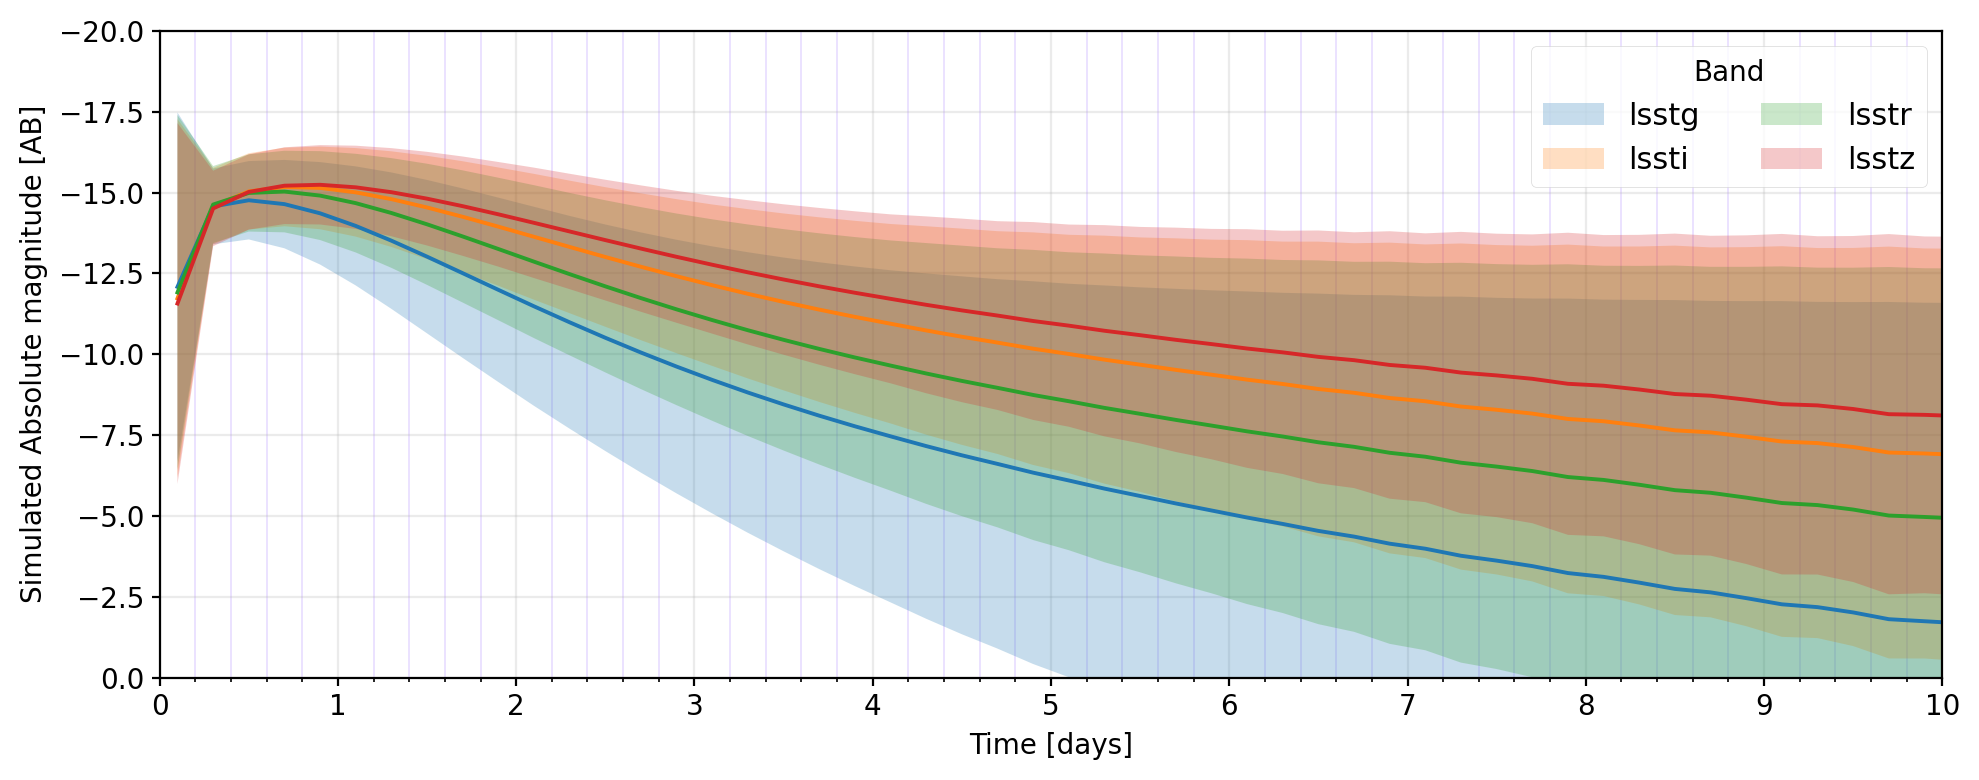

In [12]:
import matplotlib as mpl

mpl.rcParams["text.usetex"] = False

ks.plot_simulations_LCS(data_sim_all)

#### Loading Observational Data:

In [13]:
#AT2025ulz & S250818k
MERGER_TIME_MJD = 60905.055961        
DL_Mpc = 259.0                 
err_DL_Mpc = 62.0    
gw_id = "S250818K"
bin_size = 0.2
k_near = 3.0

data_obs = ks.load_observations(
    file_path='/tf/phelipedock/KilonovaScorer_Northwestern/Data/SN2025ulz.json', 
    merger_mjd=MERGER_TIME_MJD, 
    dist_mpc=DL_Mpc, 
    dist_err_mpc=err_DL_Mpc
)
# Standardize observation bands using the same dictionary
data_obs['filter_mapped'] = data_obs['band'].str.lower().map(FILTER_LOOKUP)

Loading Data:  /tf/phelipedock/KilonovaScorer_Northwestern/Data/SN2025ulz.json


In [14]:
data_obs

,time,time_after_gw,magnitude,e_magnitude,band,instrument,telescope,absolute_magnitude,absolute_magnitude_error,filter_mapped
0,60905.243171,0.187210,21.293900,0.125305,r-ztf,unknown,unknown,-15.695934,0.599915,r-band
1,60905.188368,0.132407,20.991100,0.126861,g-ztf,unknown,unknown,-16.013038,0.577899,g-band
2,60907.314130,2.258169,22.050000,0.200000,r-p1,unknown,unknown,-14.929338,0.611511,r-band
3,60922.243724,17.187763,20.180387,0.291696,o,unknown,unknown,-16.798829,0.647660,NaN
4,60915.003200,9.947239,21.036300,0.278300,i,unknown,unknown,-15.945421,0.619685,i-band
5,60912.876170,7.820209,21.369400,0.276800,i,unknown,unknown,-15.630608,0.623112,i-band
6,60924.828720,19.772759,20.696000,0.228900,i,unknown,unknown,-16.319529,0.602592,i-band
7,60912.864760,7.808799,21.452400,0.444300,r,unknown,unknown,-15.525825,0.747400,r-band
8,60924.821110,19.765149,20.640000,0.228700,r,unknown,unknown,-16.354932,0.612503,r-band
9,60905.816100,0.760139,21.430000,0.060000,r,unknown,unknown,-15.563336,0.556074,r-band


####  `KilonovaSCORER` Calculations:

In [15]:
import time

t0 = time.perf_counter()


band_list_obs = ("g-band", "r-band", "i-band", "z-band")

metric_df, overlap_df = ks.kilonovascorer_v1(
    data_obs,
    data_sim_all,
    'AT2025ulz',
    time_bin_width=bin_size,
    band_list=band_list_obs,
    k_near=k_near,
    n_kde_sim=5000,
    min_sim_points=20,
    overlap_k=1.5
)
overlap_df= pd.DataFrame(overlap_df)

binned_stats = ks.binned_stats_cumulative_ptail(metric_df,bin_size=0.2)

dt = time.perf_counter() - t0
print(f"Elapsed time: {dt:.3f} s")

[ -------------------------------------------------- ]   0.00% ⬛Elapsed time: 155.986 s


#### Visualization:

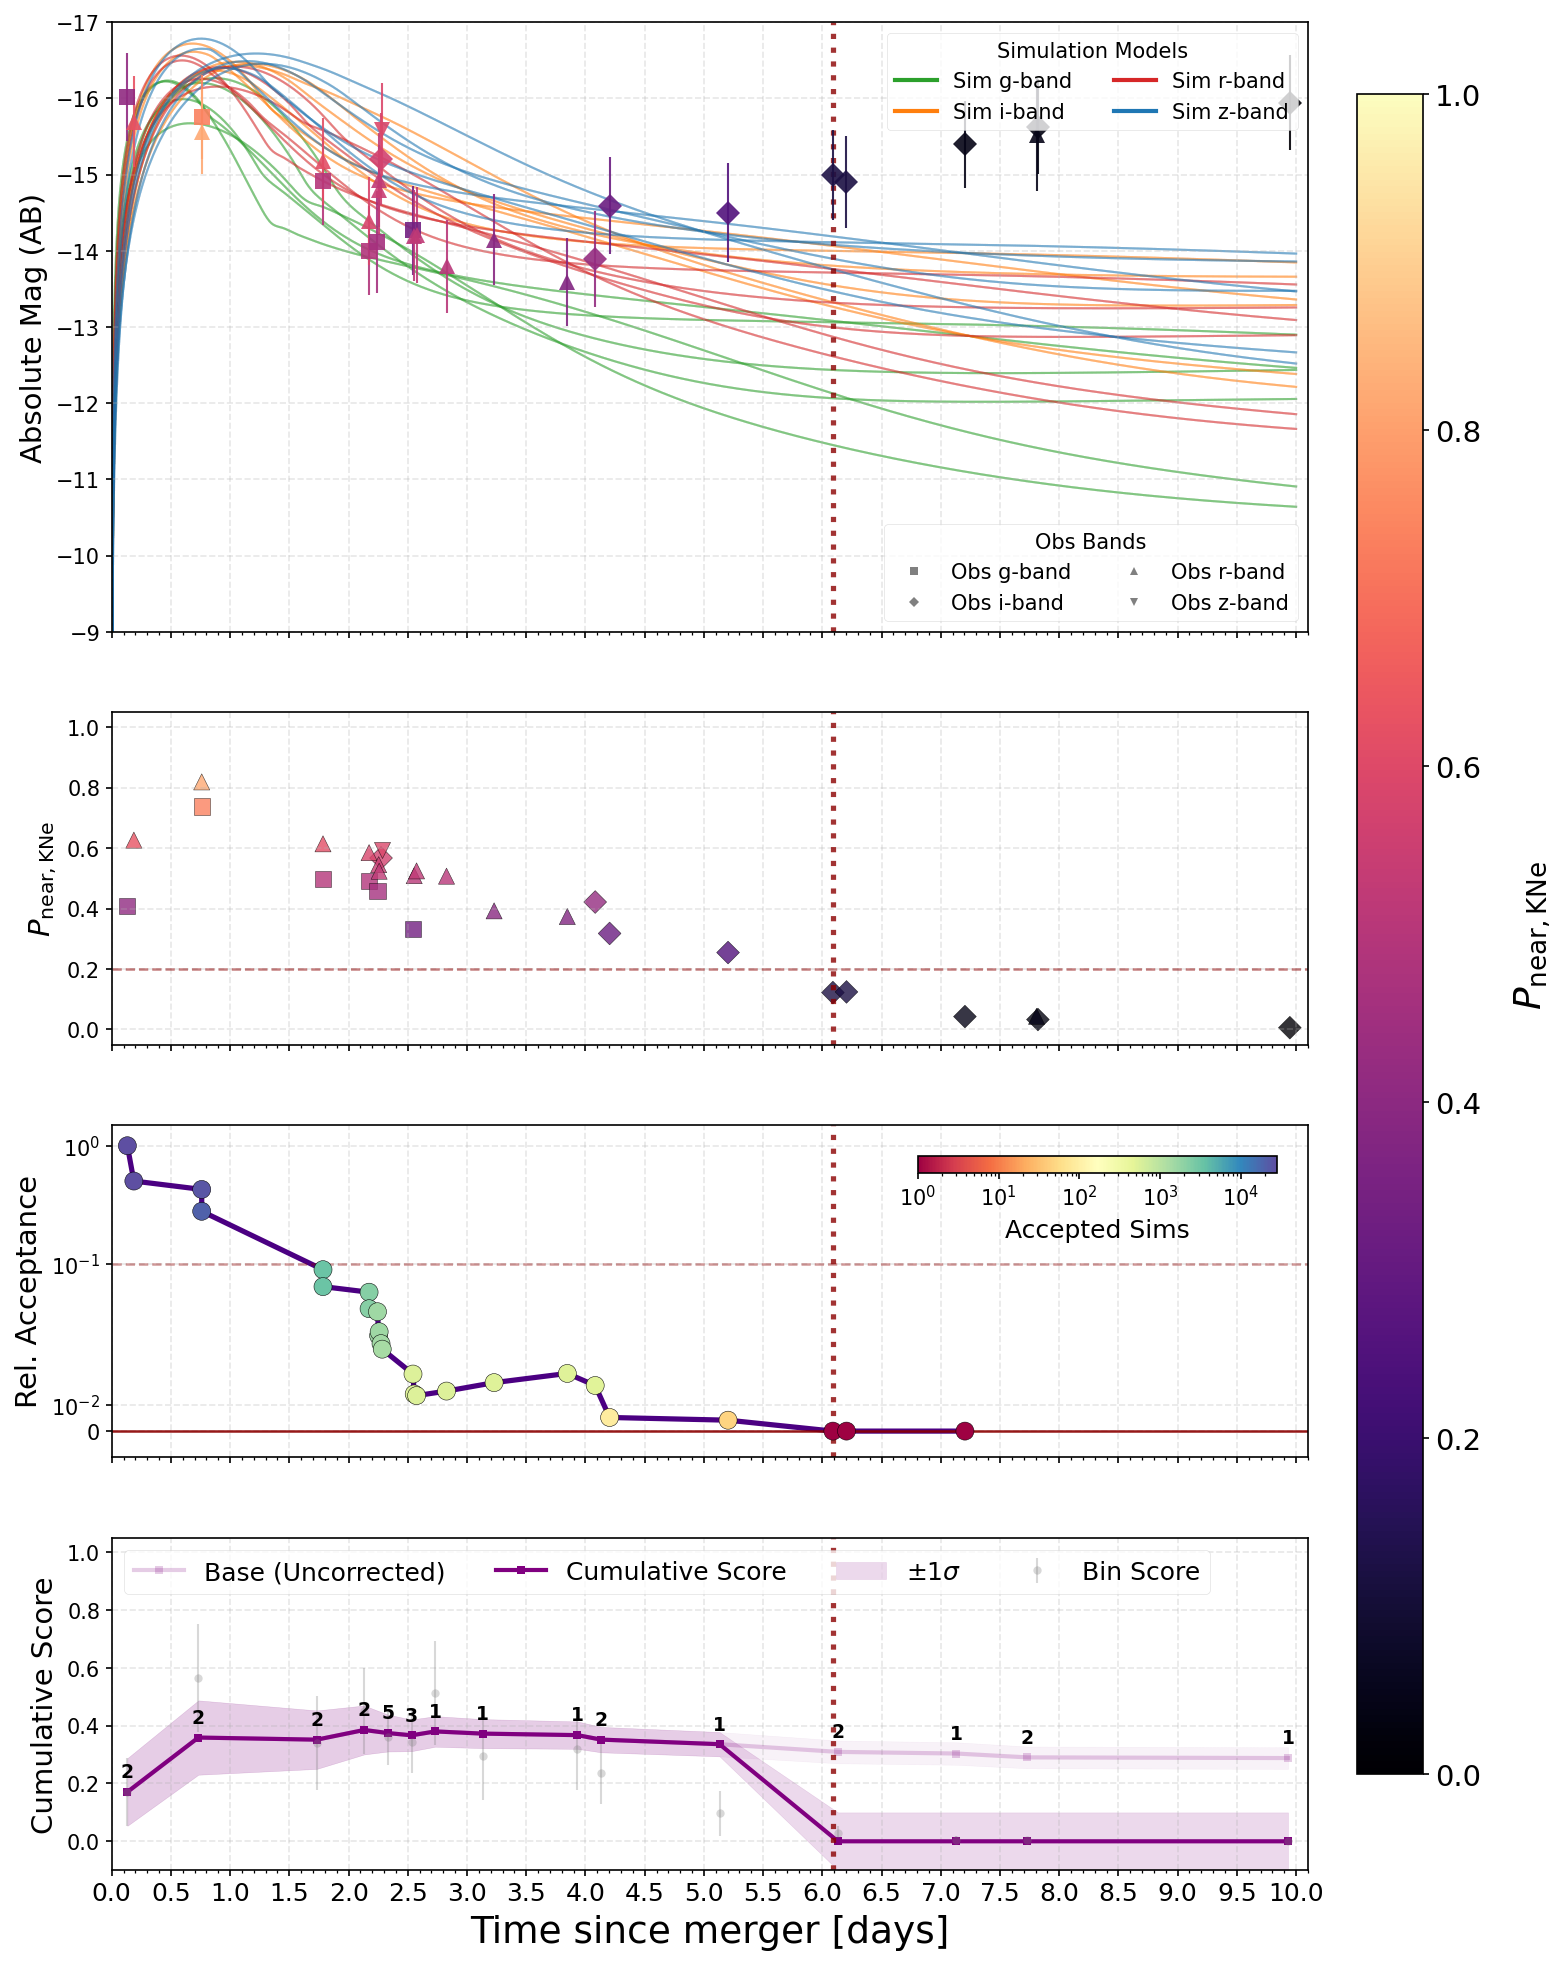

In [16]:
ks.plot_final_all_metrics(
    metric_df,
    data_sim_all,
    binned_stats,
    candidate_name='AT2025ulz',save_png=False)

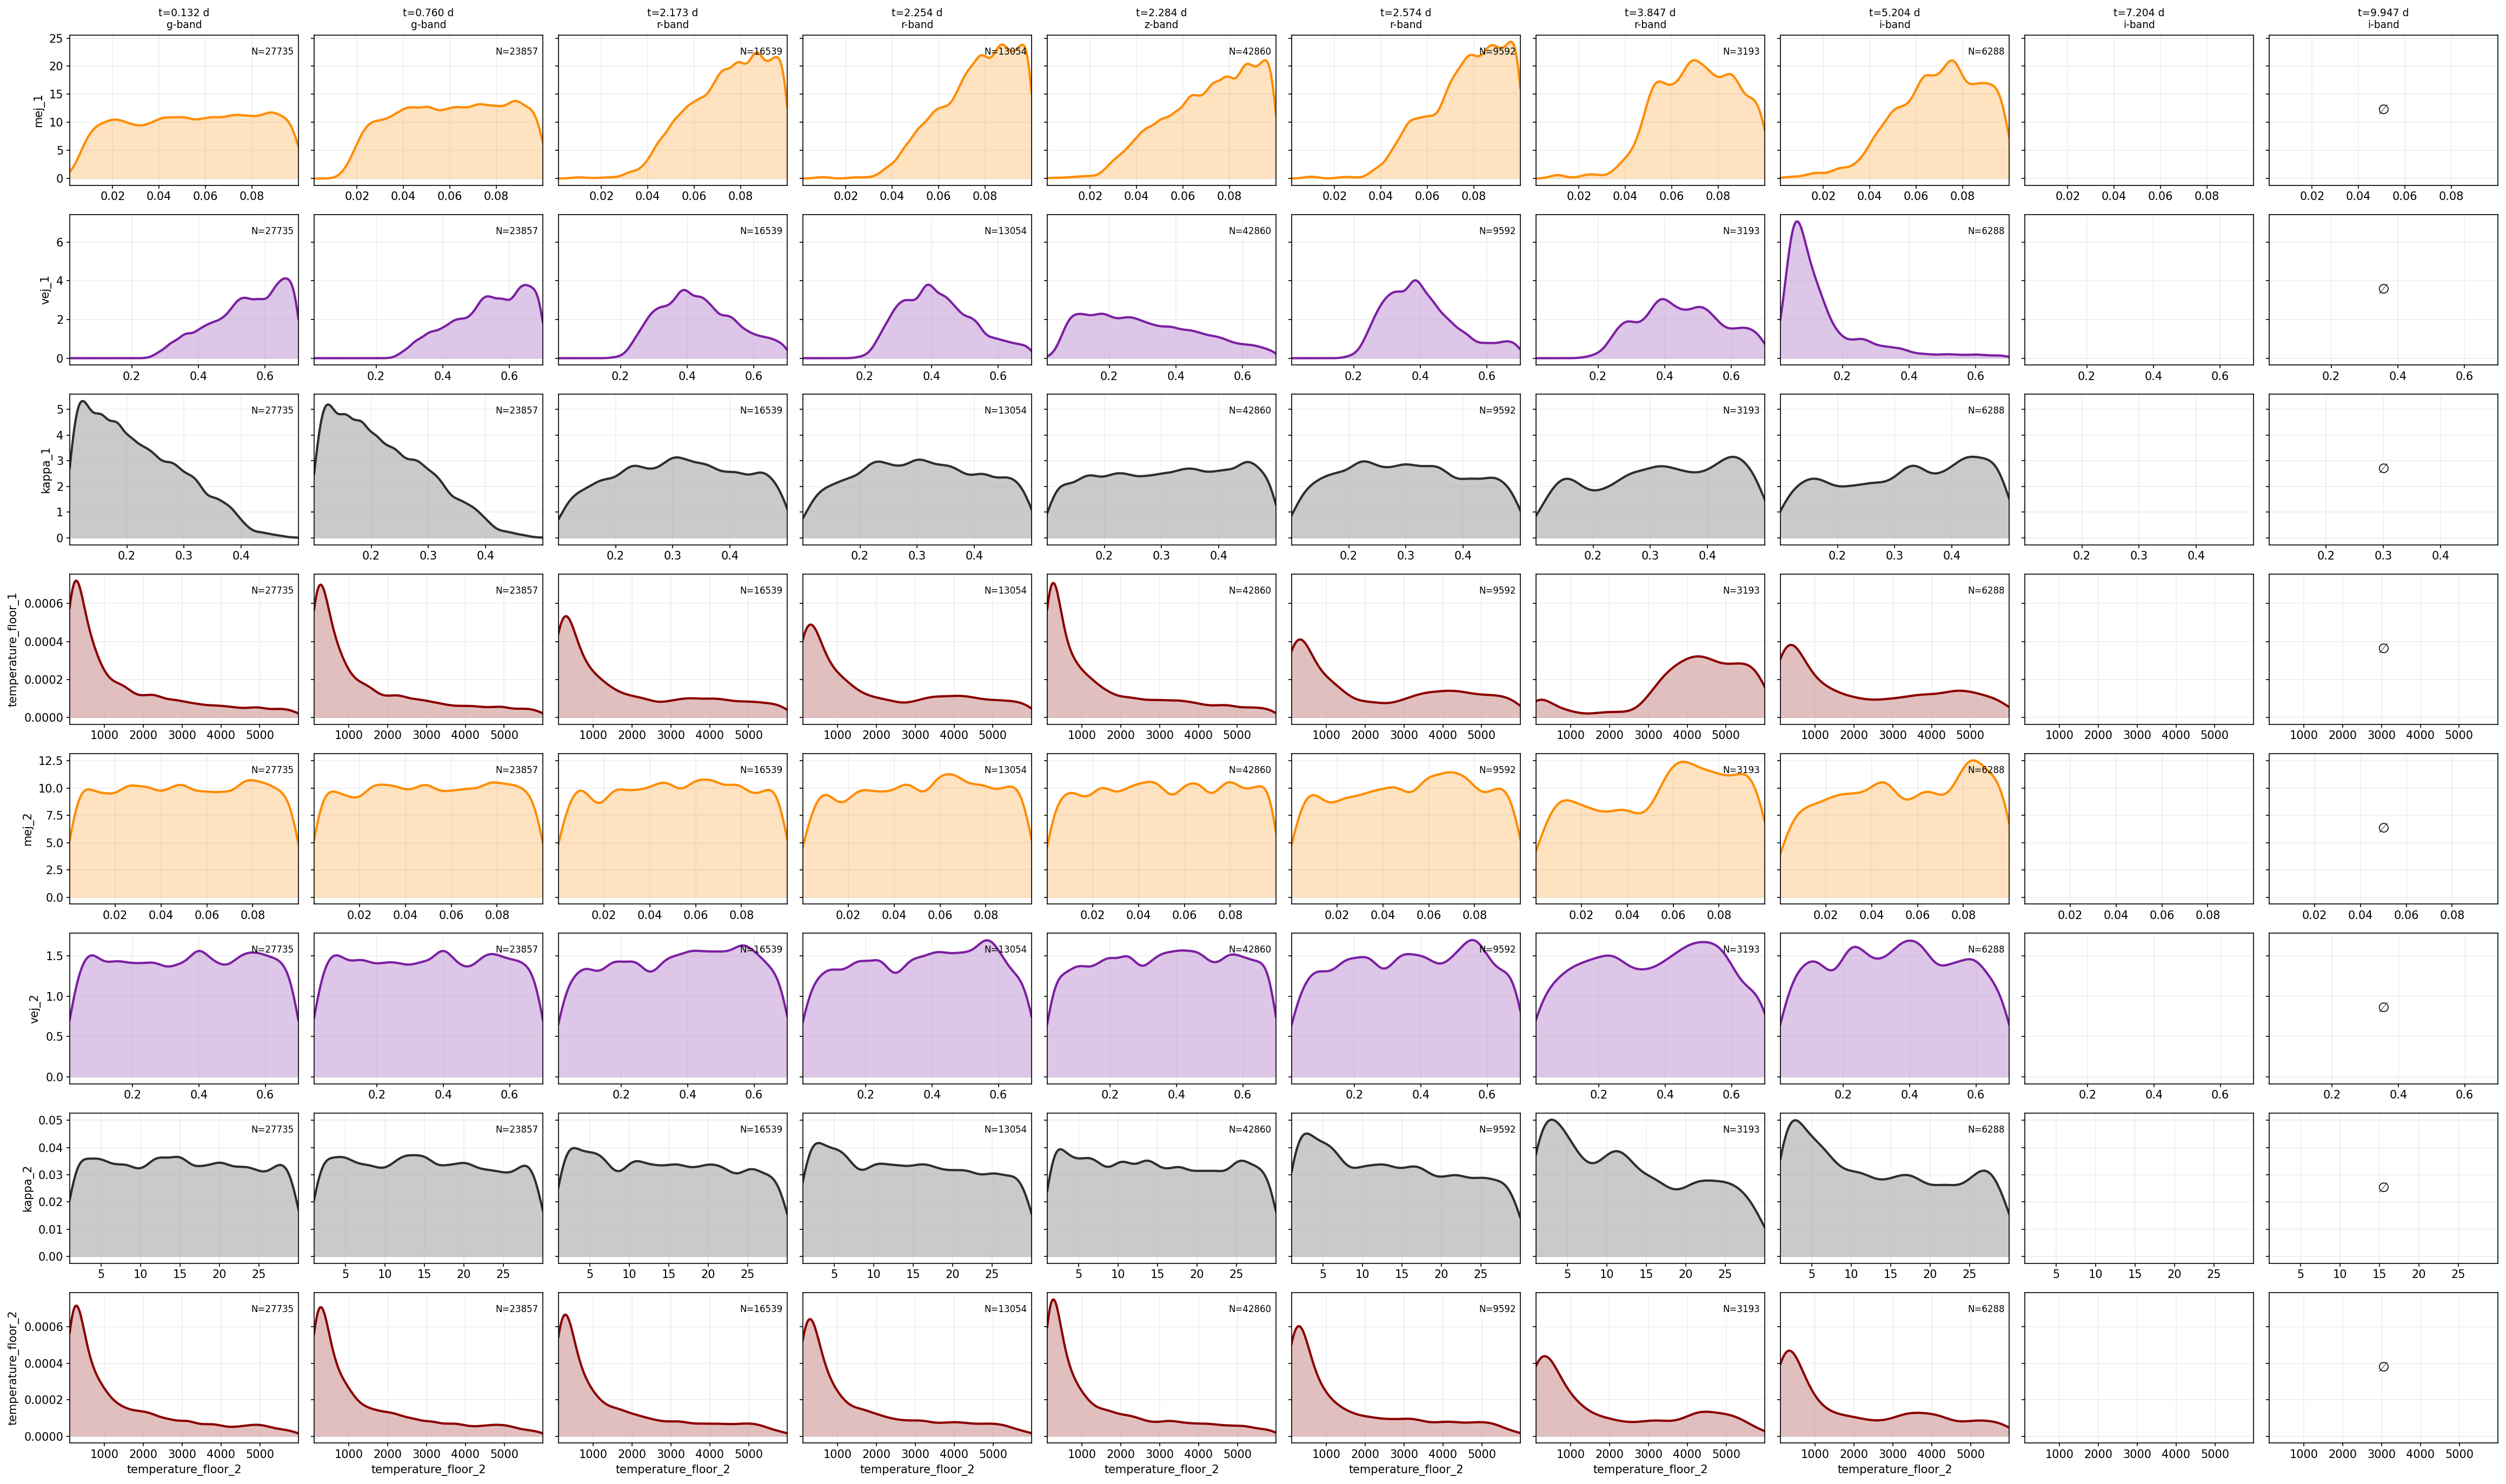

In [17]:
ks.plotting.plot_survivor_param_kde_grid(metric_df, data_sim_all,params=("mej_1", "vej_1", "kappa_1","temperature_floor_1","mej_2", "vej_2", "kappa_2", "temperature_floor_2"))

#### AT2017gfo

In [17]:
MERGER_TIME_MJD = 57982.53          
DL_Mpc = 38.589                 
err_DL_Mpc = 6.997    
gw_id = "GW170817"
bin_size = 0.2
k_near = 3.0
    
obs_path='Data/at2017gfo.csv'
data_obs = ks.load_observations(
    file_path=obs_path, 
    merger_mjd=MERGER_TIME_MJD, 
    dist_mpc=DL_Mpc, 
    dist_err_mpc=err_DL_Mpc
)
# Standardize observation bands using the same dictionary
data_obs['filter_mapped'] = data_obs['band'].str.lower().map(FILTER_LOOKUP)
data_obs = data_obs[(data_obs['system']=='AB')&(data_obs['filter_mapped'].isin(['g-band','r-band','i-band','z-band']))&(data_obs['time_after_gw']<10.0)].reset_index(drop=True)
data_obs = data_obs.dropna() 

Loading Data:  Data/at2017gfo.csv


##### All observations

In [18]:
import time

t0 = time.perf_counter()

band_list_obs = ("g-band", "r-band", "i-band", "z-band")

metric_df2, overlap_df2 = ks.kilonovascorer_v1(
    data_obs,
    data_sim_all,
    'AT2017gfo',
    time_bin_width=bin_size,
    band_list=band_list_obs,
    k_near=k_near,
    n_kde_sim=5000,
    min_sim_points=20,
    overlap_k=1.5
)
overlap_df2 = pd.DataFrame(overlap_df2)
binned_stats2 = ks.binned_stats_cumulative_ptail(metric_df2,bin_size=0.2)
dt = time.perf_counter() - t0
print(f"Elapsed time: {dt:.3f} s")

Elapsed time: 330.300 s


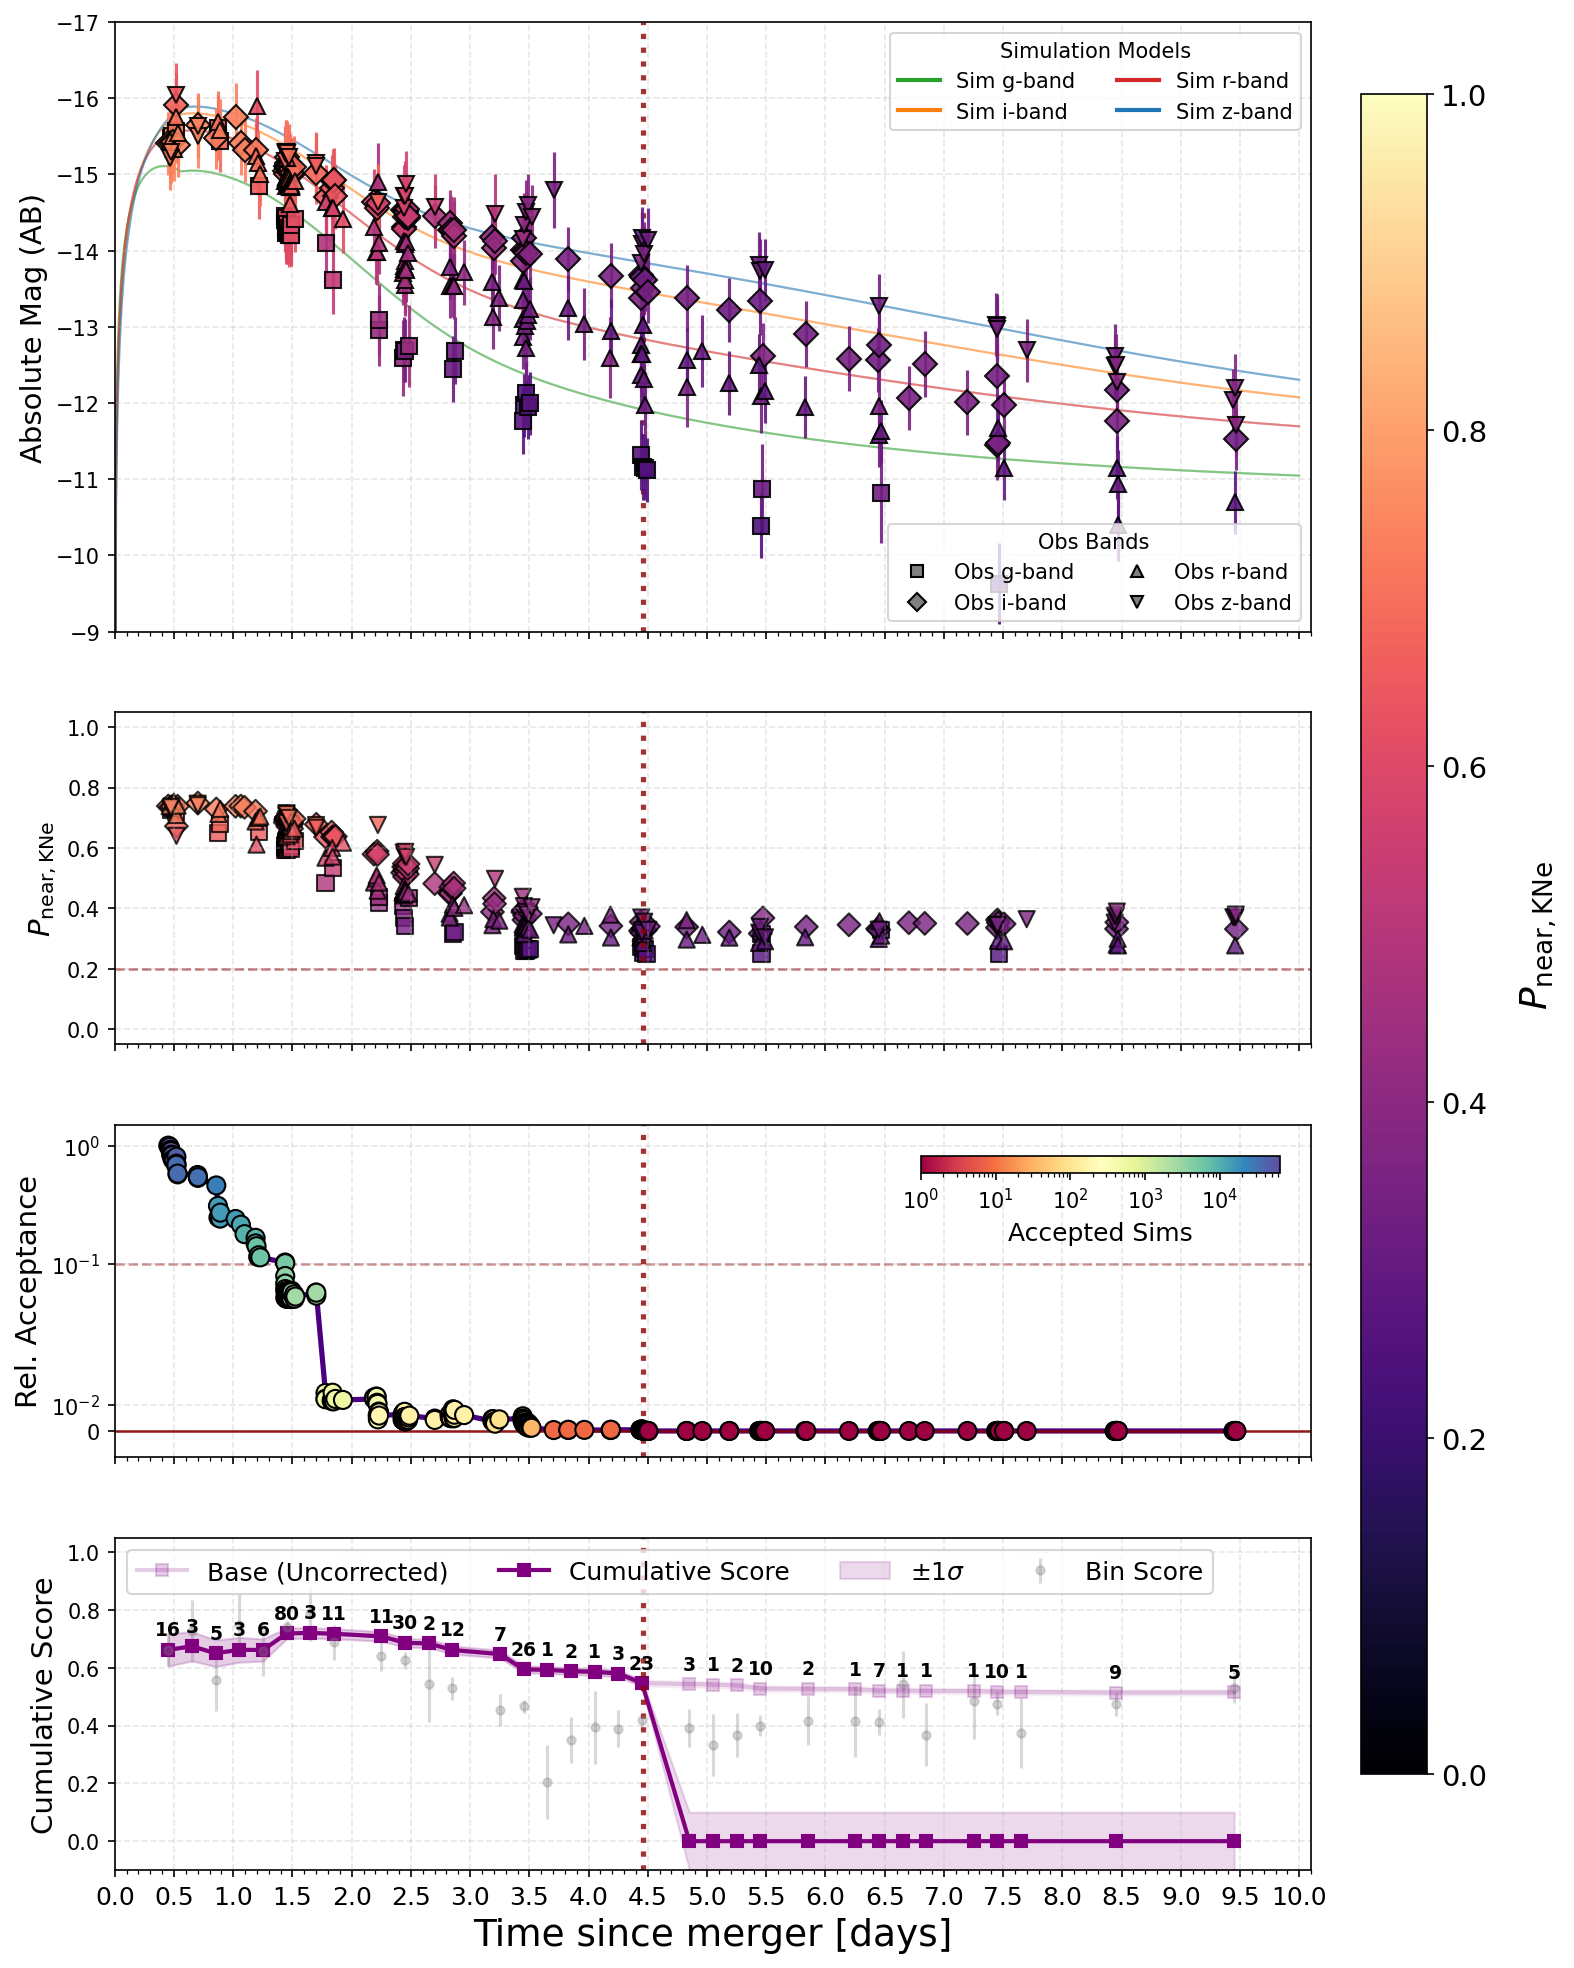

In [19]:
ks.plot_final_all_metrics(
    metric_df2,
    data_sim_all,
    binned_stats2,
    candidate_name='AT2017gfo')

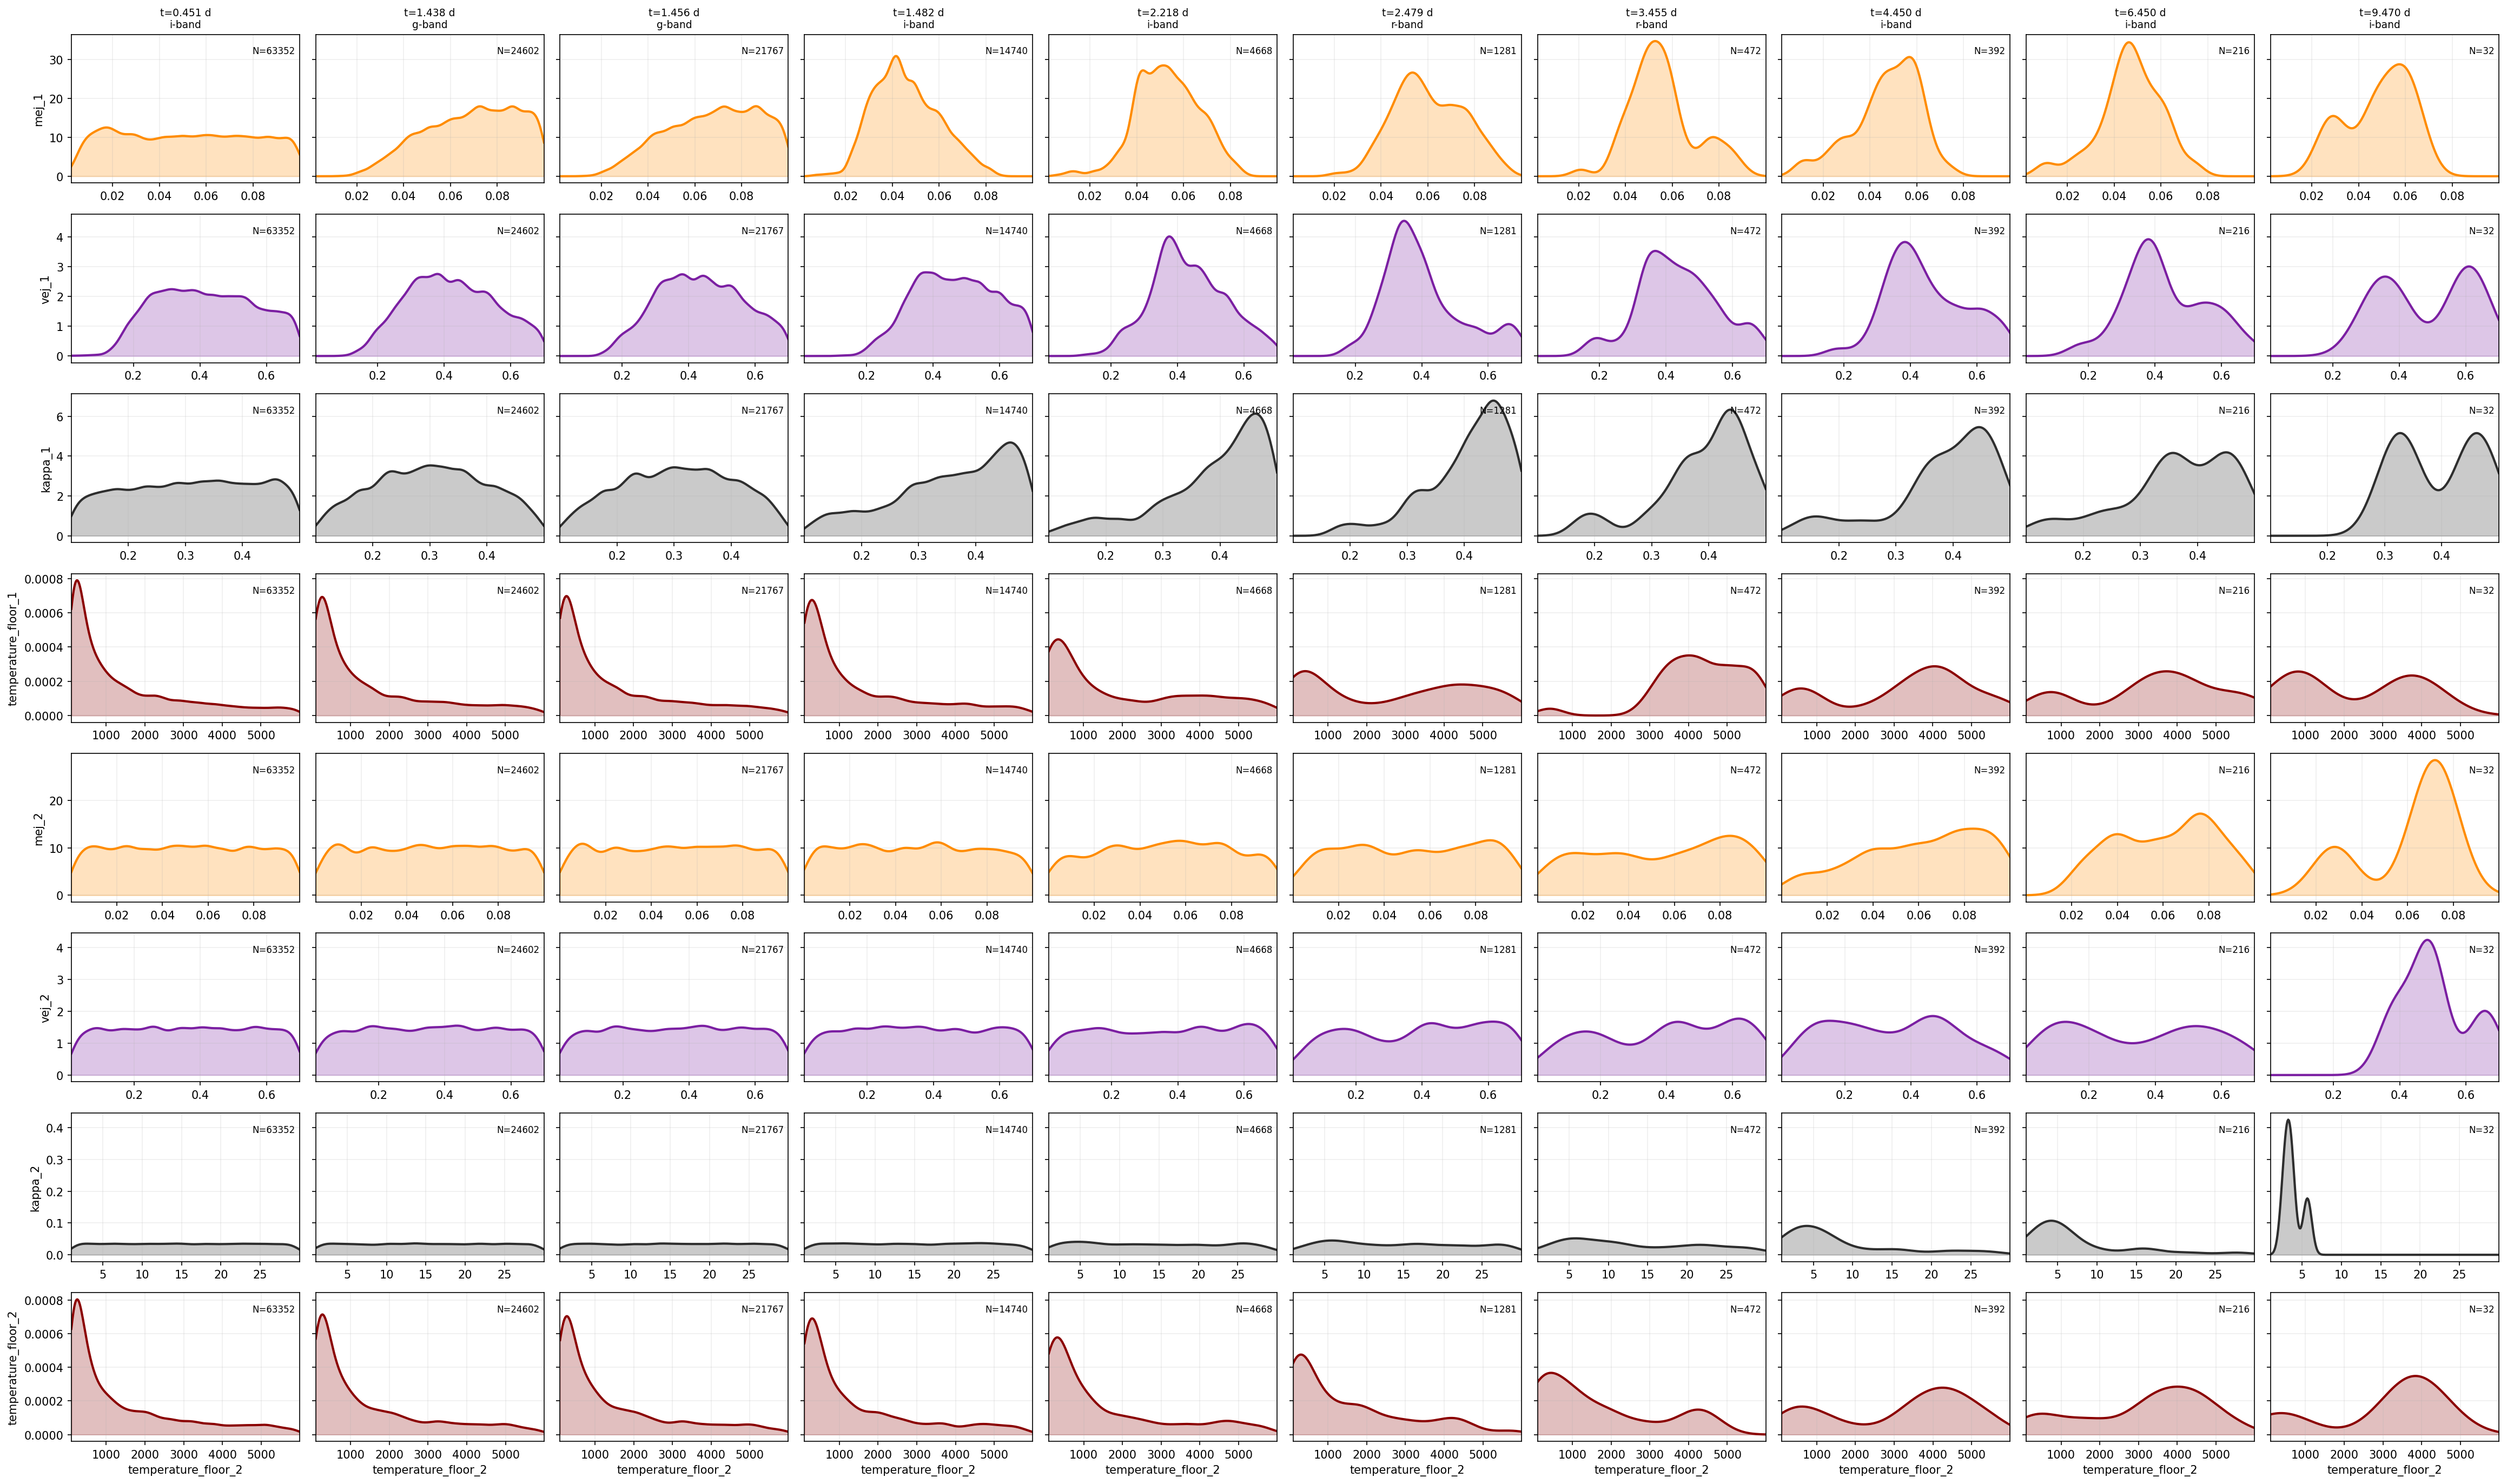

In [21]:
ks.plotting.plot_survivor_param_kde_grid(metric_df2, data_sim_all,params=("mej_1", "vej_1", "kappa_1", 
     "temperature_floor_1","mej_2", "vej_2", "kappa_2", "temperature_floor_2"))

##### LSST-Like At2017gfo

In [22]:
#bands=("g-band", "r-band",'i-band','z-band','y-band','u-band'),
data_obs_lsst = ks.preprocess_lsst_like(
    data_obs,
    bands=("g-band",'z-band'),
    strategy="snr"
)

In [25]:
import time

t0 = time.perf_counter()

band_list_obs = ("g-band", "r-band", "i-band", "z-band")

metric_df20, overlap_df20 = ks.kilonovascorer_v1(
    data_obs_lsst,
    data_sim_all,
    'AT2017gfo',
    time_bin_width=bin_size,
    band_list=band_list_obs,
    k_near=k_near,
    n_kde_sim=5000,
    min_sim_points=20,
    overlap_k=1.5
)
overlap_df20 = pd.DataFrame(overlap_df20)
binned_stats20 = ks.binned_stats_cumulative_ptail(metric_df20,bin_size=0.2)
dt = time.perf_counter() - t0
print(f"Elapsed time: {dt:.3f} s")

Elapsed time: 139.231 s


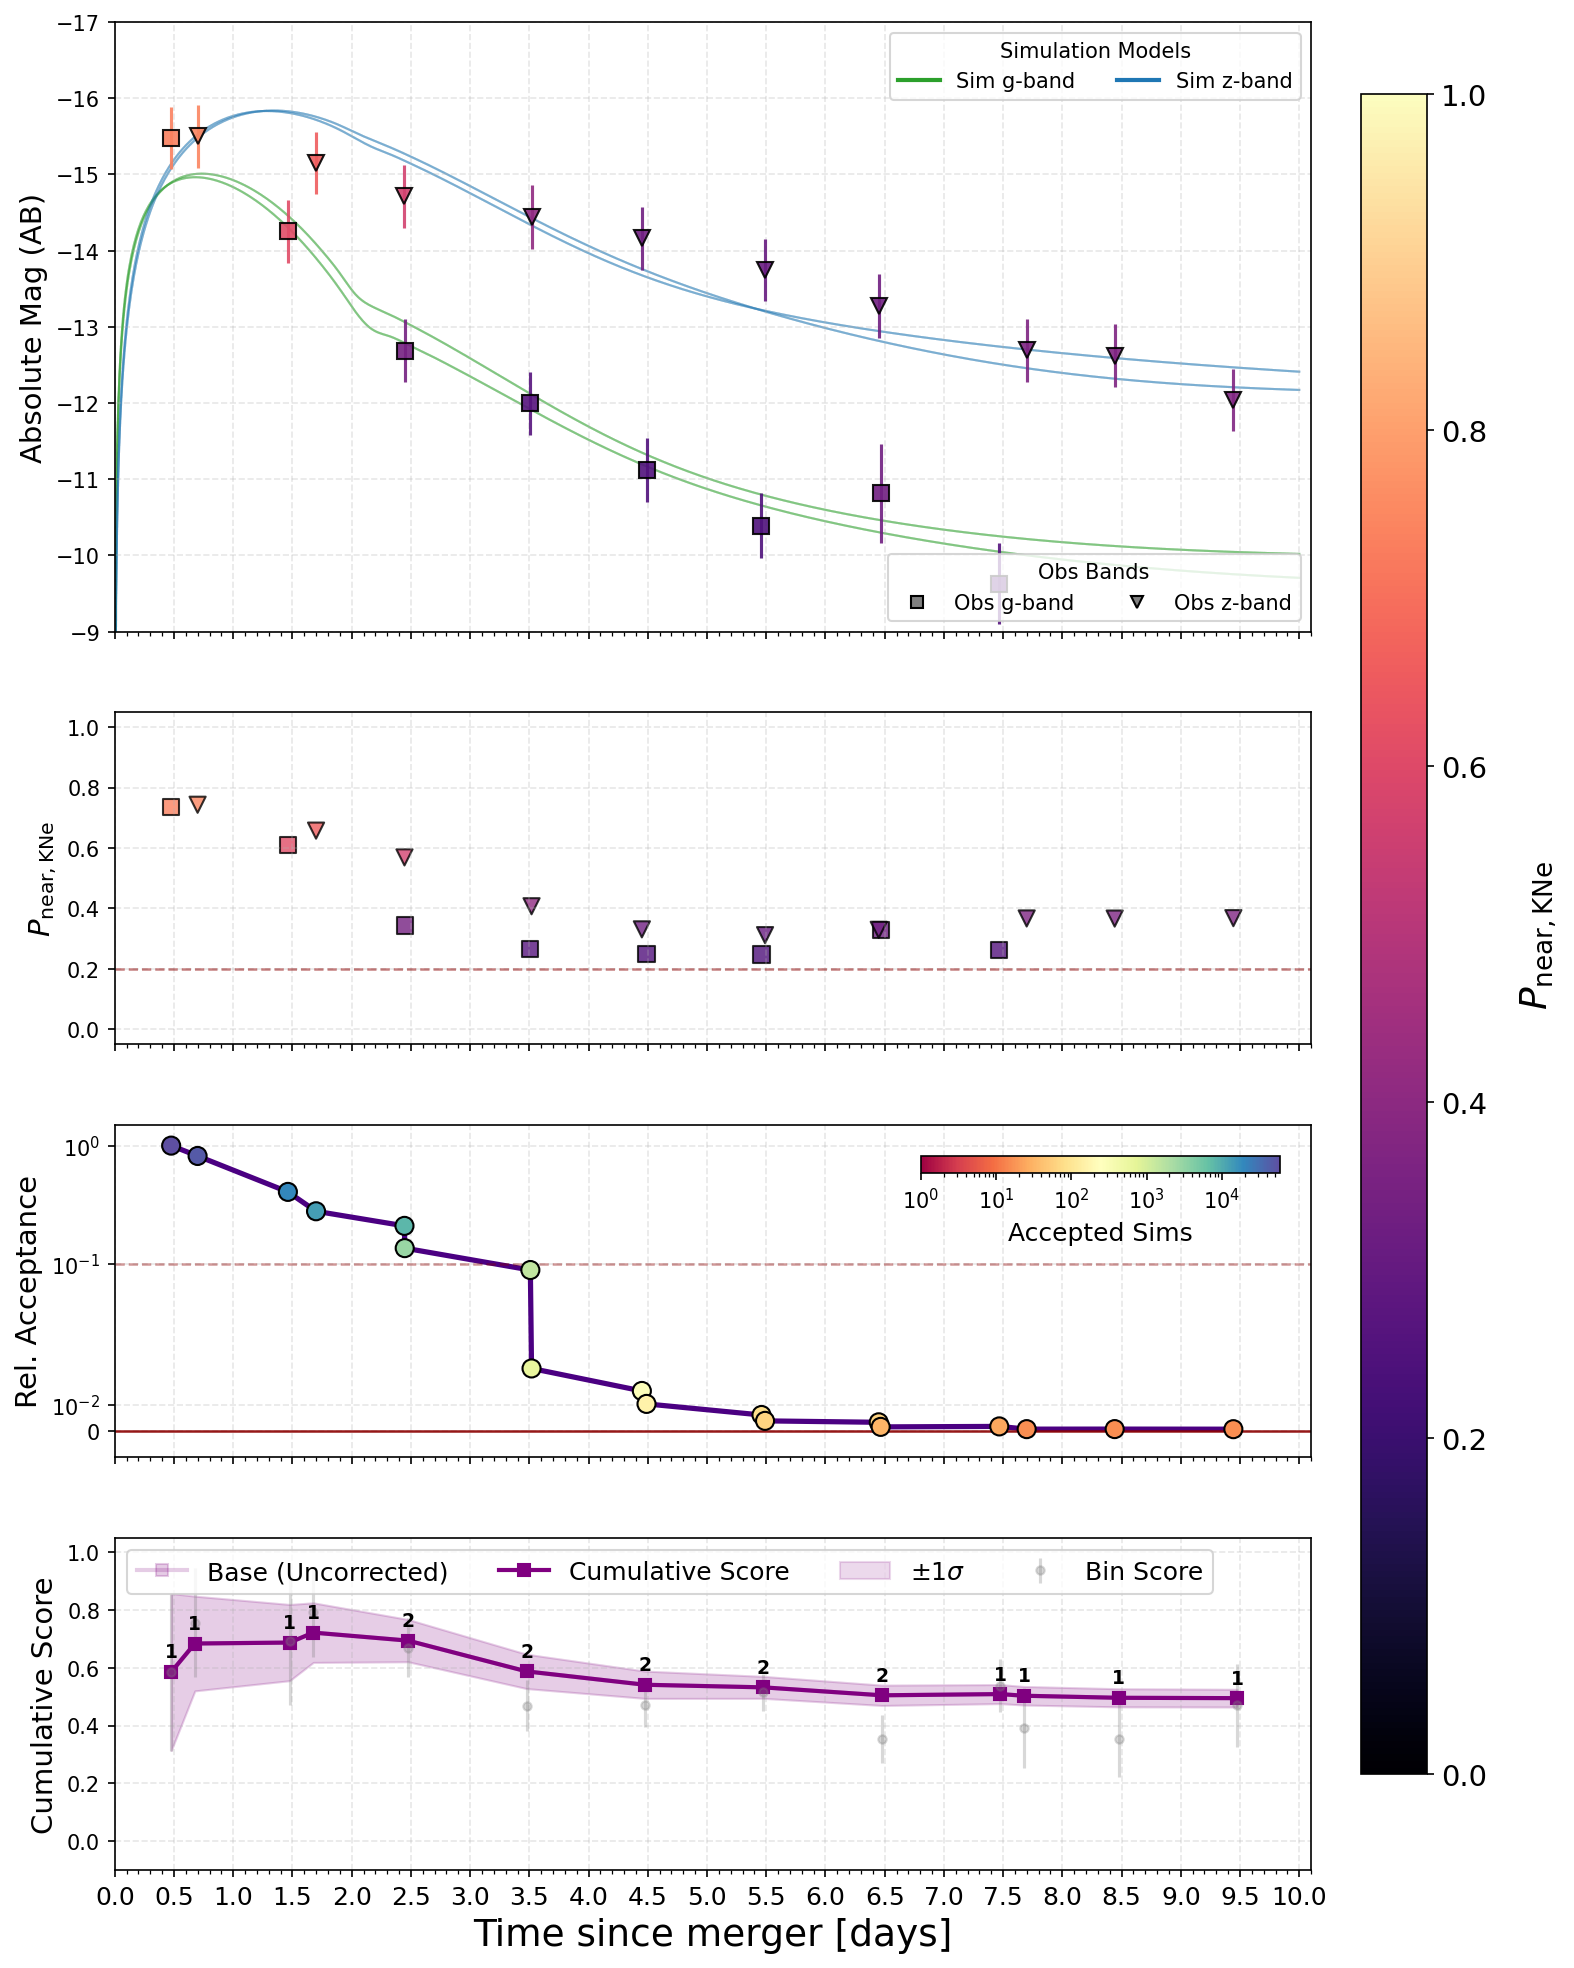

In [26]:
ks.plot_final_all_metrics(
    metric_df20,
    data_sim_all,
    binned_stats20,
    candidate_name='AT2017gfo')

##### Pick any band combination

Elapsed time: 146.123 s


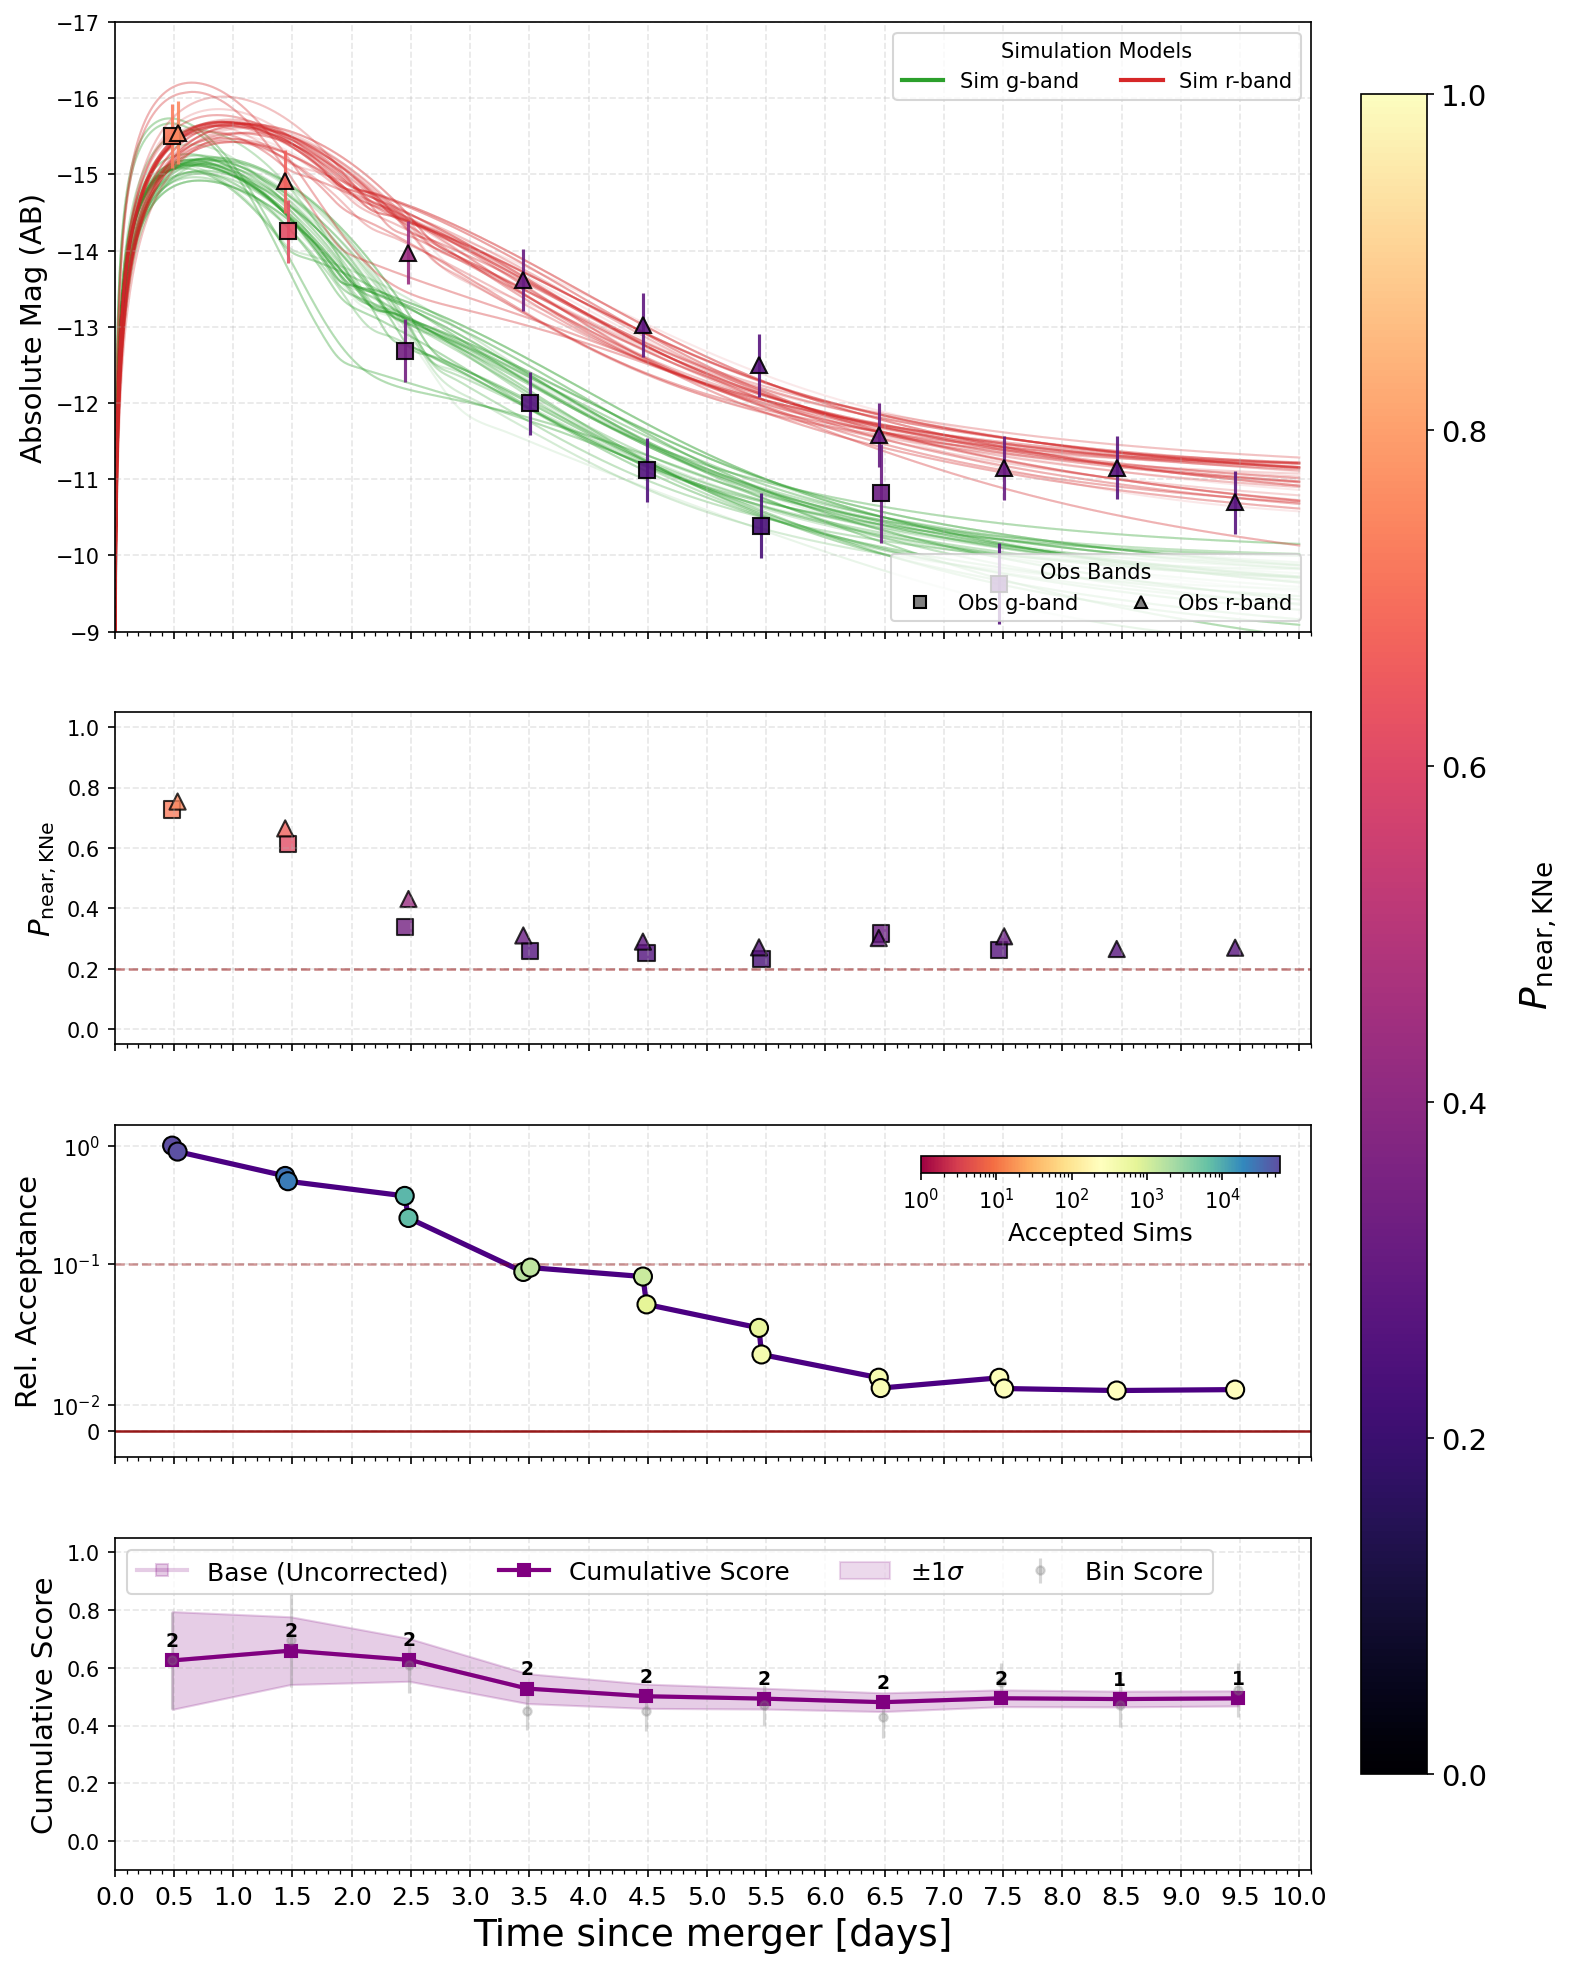

In [28]:
#bands=("g-band", "r-band",'i-band','z-band','y-band','u-band'),
data_obs_lsst = ks.preprocess_lsst_like(
    data_obs,
    bands=("g-band",'r-band'),
    strategy="snr"
)
import time

t0 = time.perf_counter()

band_list_obs = ("g-band", "r-band", "i-band", "z-band")

metric_df20, overlap_df20 =  ks.kilonovascorer_v1(
    data_obs_lsst,
    data_sim_all,
    'AT2017gfo',
    time_bin_width=bin_size,
    band_list=band_list_obs,
    k_near=k_near,
    n_kde_sim=5000,
    min_sim_points=20,
    overlap_k=1.5
)
overlap_df20 = pd.DataFrame(overlap_df20)
binned_stats20 = ks.binned_stats_cumulative_ptail(metric_df20,bin_size=0.2)
dt = time.perf_counter() - t0
print(f"Elapsed time: {dt:.3f} s")
ks.plotting.plot_final_all_metrics(
    metric_df20,
    data_sim_all,
    binned_stats20,
    candidate_name='AT2017gfo')

Elapsed time: 140.239 s


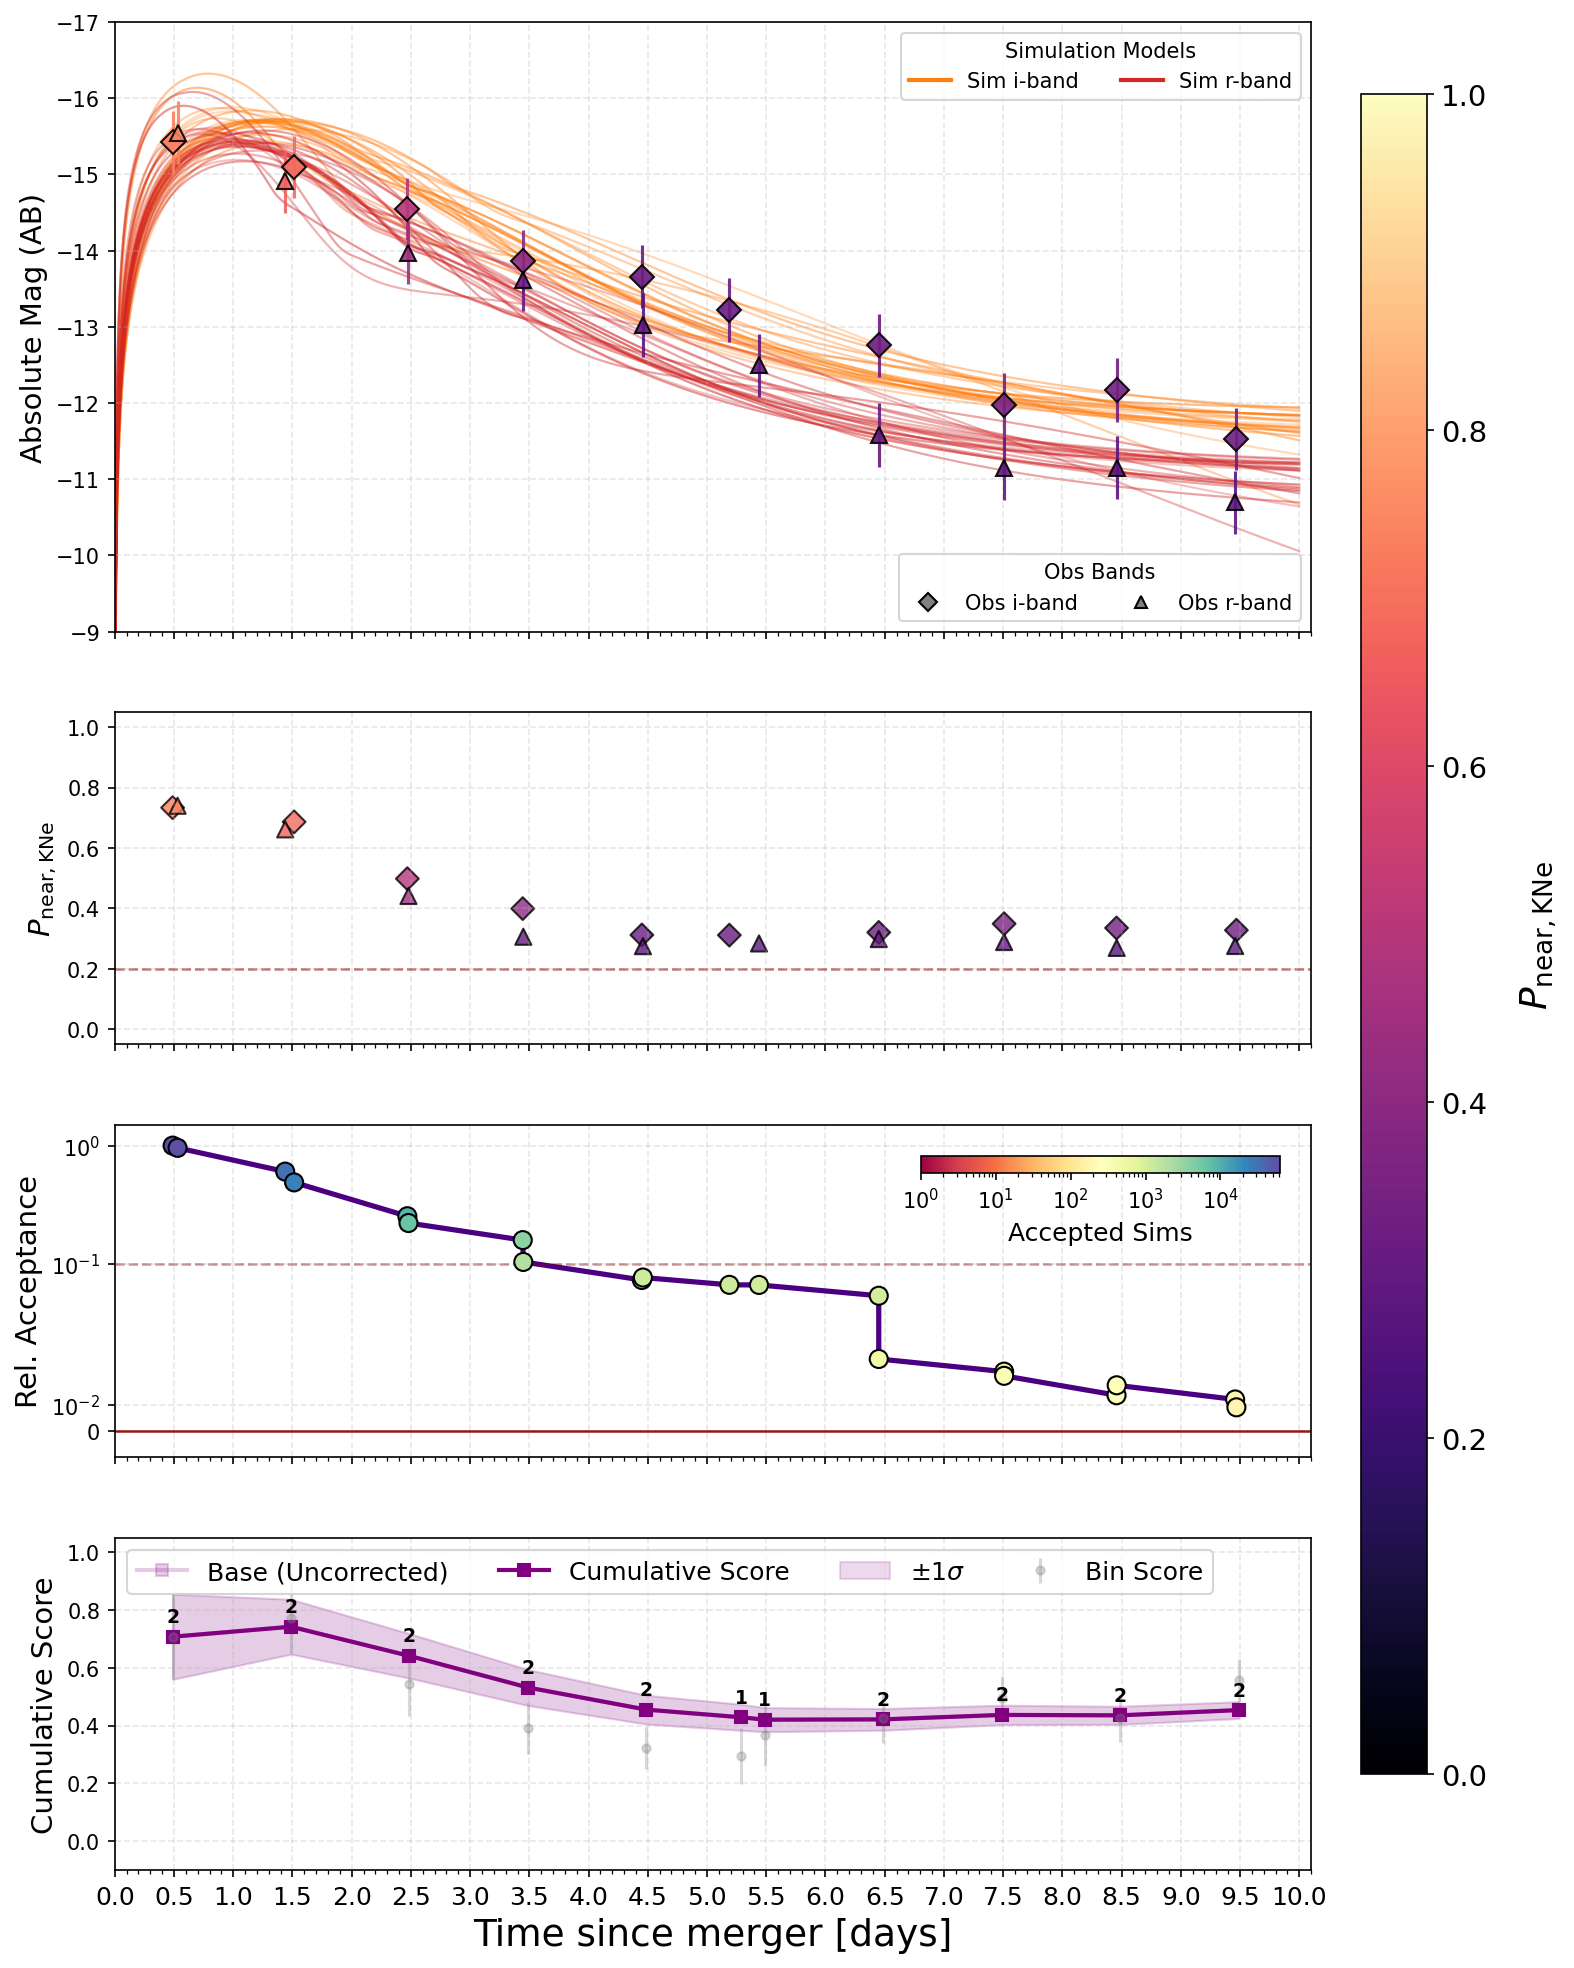

In [29]:
#bands=("g-band", "r-band",'i-band','z-band','y-band','u-band'),
data_obs_lsst = ks.preprocess_lsst_like(
    data_obs,
    bands=("r-band",'i-band'),
    strategy="snr"
)
import time

t0 = time.perf_counter()

band_list_obs = ("g-band", "r-band", "i-band", "z-band")

metric_df20, overlap_df20 =  ks.kilonovascorer_v1(
    data_obs_lsst,
    data_sim_all,
    'AT2017gfo',
    time_bin_width=bin_size,
    band_list=band_list_obs,
    k_near=k_near,
    n_kde_sim=5000,
    min_sim_points=20,
    overlap_k=1.5
)
overlap_df20 = pd.DataFrame(overlap_df20)
binned_stats20 = ks.binned_stats_cumulative_ptail(metric_df20,bin_size=0.2)
dt = time.perf_counter() - t0
print(f"Elapsed time: {dt:.3f} s")
ks.plotting.plot_final_all_metrics(
    metric_df20,
    data_sim_all,
    binned_stats20,
    candidate_name='AT2017gfo')